In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_csv("./s1_data_hw.csv", encoding="utf-8-sig")
df

,Date,SXXP Index,SPY US INDEX,NKY INDEX,XAU CURNCY,CL1 COMDTY,SPDIV,RF,DFEDTARU
0,12/31/08,276.76878,90.24,98.07993,875.43,44.60,28.390000,2.87,0.25
1,1/30/09,245.27160,82.83,88.89192,927.85,41.68,28.013333,3.02,0.25
2,2/27/09,219.88507,73.93,77.26031,942.32,44.76,27.636667,2.71,0.25
3,3/31/09,233.43893,79.52,81.62587,919.90,49.66,27.260000,3.16,0.25
4,4/30/09,264.48381,87.42,89.27354,887.95,51.12,26.703333,3.47,0.25
...,...,...,...,...,...,...,...,...,...
200,8/29/25,643.77383,645.05,290.77987,3447.95,64.01,78.103333,4.16,4.25
201,9/30/25,656.25223,666.18,304.13314,3846.09,62.37,78.480000,4.11,4.00
202,10/31/25,659.04604,682.06,340.11252,4002.92,60.98,78.626720,4.02,4.00
203,11/28/25,668.83173,683.39,321.70738,4239.43,58.55,78.773440,4.18,3.75


In [3]:
from homework01 import (
    monthly_log_return, wti_plots, testing_avg_ret_stoxx, 
    testing_CI_avg_ret_gold, correlation_matrix_risky_assets, 
    highest_kurtoisis, plot_kutosis_vs_normal, highest_jarque_bera,
    hike_cut_identification, label_hiking_months, analyze_monetary_regimes
)

In [4]:
monthly_returns, df_adjusted = monthly_log_return(df)

Mean monthly log return STOXX600: 0.0033
Mean monthly log return NIKKEI: 0.0053


In [5]:
monthly_returns.head()

,Date,RF_monthly,SP500_monthly_log_return,STOXX600_monthly_log_return,NIKKEI_monthly_log_return,GOLD_monthly_log_return,WTI_monthly_log_return
0,2011-02-28,0.002892,0.0341,0.0296,0.0385,0.0544,0.0505
1,2011-03-31,0.002767,-0.0042,-0.0091,-0.0972,0.0182,0.0958
2,2011-04-29,0.002542,0.0286,0.0720,0.0251,0.0840,0.0654
3,2011-05-31,0.002650,-0.0113,-0.0411,-0.0133,-0.0177,-0.1038
4,2011-06-30,0.002350,-0.0220,-0.0197,0.0222,-0.0207,-0.0735


In [6]:
df_adjusted.head()

,Date,SXXP Index,SPY US INDEX,NKY INDEX,XAU CURNCY,CL1 COMDTY,SPDIV,RF,DFEDTARU,RF_monthly,SP500_monthly_log_return,STOXX600_monthly_log_return,NIKKEI_monthly_log_return,GOLD_monthly_log_return,WTI_monthly_log_return
25,2011-01-31,383.58449,128.68,124.89838,1337.14,92.19,22.963333,3.42,0.25,0.002850,NaN,NaN,NaN,NaN,NaN
26,2011-02-28,395.09942,133.15,129.79951,1411.88,96.97,23.196667,3.47,0.25,0.002892,0.0341,0.0296,0.0385,0.0544,0.0505
27,2011-03-31,391.50210,132.59,117.77255,1437.78,106.72,23.430000,3.32,0.25,0.002767,-0.0042,-0.0091,-0.0972,0.0182,0.0958
28,2011-04-29,420.73223,136.43,120.76680,1563.70,113.93,23.733333,3.05,0.25,0.002542,0.0286,0.0720,0.0251,0.0840,0.0654
29,2011-05-31,403.79890,134.90,119.17544,1536.23,102.70,24.036667,3.18,0.25,0.002650,-0.0113,-0.0411,-0.0133,-0.0177,-0.1038


In [7]:
def monthly_log_return(df):
    """Return monthly log returns from January 2011 onward."""
    data = df.copy()
    data = data.rename(columns=lambda col: col.strip().replace("\ufeff", ""))
    data["Date"] = pd.to_datetime(data["Date"], format="%m/%d/%y")
    data = data.sort_values("Date")
    start_date = pd.Timestamp("2011-01-01")
    data = data[data["Date"] >= start_date].copy()
    data["RF_monthly"] = (data["RF"] / 100) / 12

    assets = {
        "SP500": "SPY US INDEX",
        "STOXX600": "SXXP Index",
        "NIKKEI": "NKY INDEX",
        "GOLD": "XAU CURNCY",
        "WTI": "CL1 COMDTY",
    }

    for label, column in assets.items():
        #log_returns = np.log(data[column]).diff().round(4)
        log_returns = np.log(data[column]).diff()
        data[f"{label}_monthly_log_return"] = log_returns

    result_cols = ["Date", "RF_monthly"] + [f"{label}_monthly_log_return" for label in assets]
    result = data[result_cols].dropna().reset_index(drop=True)

    sto_mean = result["STOXX600_monthly_log_return"].mean()
    nky_mean = result["NIKKEI_monthly_log_return"].mean()
    print(f"Mean monthly log return STOXX600: {sto_mean:.4f}")
    print(f"Mean monthly log return NIKKEI: {nky_mean:.4f}")

    return result, data


def wti_plots(df):
    price_series = df[["Date", "CL1 COMDTY"]].dropna()
    return_series = df.dropna(subset=["WTI_monthly_log_return"])

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    axes[0].plot(price_series["Date"], price_series["CL1 COMDTY"], color="tab:blue")
    axes[0].axhline(price_series["CL1 COMDTY"].mean(), color="black", linewidth=0.8, linestyle="--")
    axes[0].set_title("WTI Price Index")
    axes[0].set_ylabel("Index Level")

    axes[1].plot(return_series["Date"], return_series["WTI_monthly_log_return"], color="tab:orange")
    axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_title("WTI Monthly Log Returns")
    axes[1].set_ylabel("Log Return")
    axes[1].set_xlabel("Date")

    plt.tight_layout()
    plt.show()

    max_idx = return_series["WTI_monthly_log_return"].abs().idxmax()
    max_date = return_series.loc[max_idx, "Date"].strftime("%b %Y")
    max_value = return_series.loc[max_idx, "WTI_monthly_log_return"]
    print(
        "WTI returns show a pronounced spike of "
        f"{max_value:.2%} around {max_date}, highlighting their volatility.\n"
    )


def testing_avg_ret_stoxx(df): 
    # HYPOTHESIS:
    # H_0:= mu = 0 
    # H_1:= mu != 0

    significance_level = 0.05
    t, p = stats.ttest_1samp(df["STOXX600_monthly_log_return"], popmean=0.0)

    print(f"t-statistic: ${t}\n")
    print(f"p-value: ${p}\n")
    if p < significance_level:
        print("REJECT H_0\n")
    else: 
        print("FAILED TO REJECT H_0\n")
    
    # *spoiler*: we fail to reject the H_0 => H_0 is likely


def testing_CI_avg_ret_gold(df): 
    level = 0.95
    gold_returns = df["GOLD_monthly_log_return"].dropna()
    n = gold_returns.count()
    mean_value = gold_returns.mean()
    se = gold_returns.std(ddof=1) / np.sqrt(n)
    a, b = stats.t.interval(level, n - 1, loc=mean_value, scale=se)
    
    print(f"CI-Testing: 2.5th percentile: ${a}\n")
    print(f"CI-Testing: 97.5th percentile: ${b}\n")
    rf_mean = df["RF_monthly"].mean()
    print(f"Average monthly risk-free rate: {rf_mean:.4f}")
    if a > rf_mean:
        print("Gold's mean return exceeds the risk-free rate at the 95% confidence level.\n")
    else:
        print("Cannot claim Gold outperformed the risk-free rate at the 95% confidence level.\n")

def correlation_matrix_risky_assets(monthly_returns): 
    risky_cols = [
        "SP500_monthly_log_return",
        "STOXX600_monthly_log_return",
        "NIKKEI_monthly_log_return",
        "GOLD_monthly_log_return",
        "WTI_monthly_log_return",
    ]
    
    correlation_matrix = monthly_returns[risky_cols].corr()
    return correlation_matrix

In [8]:
correlation_matrix = correlation_matrix_risky_assets(monthly_returns)
wti_max_corr = (
    correlation_matrix["WTI_monthly_log_return"]
    .drop("WTI_monthly_log_return")
    .idxmax()
)

In [9]:
correlation_matrix

,SP500_monthly_log_return,STOXX600_monthly_log_return,NIKKEI_monthly_log_return,GOLD_monthly_log_return,WTI_monthly_log_return
SP500_monthly_log_return,1.000000,0.818254,0.713326,0.104161,0.402944
STOXX600_monthly_log_return,0.818254,1.000000,0.693615,0.225039,0.441467
NIKKEI_monthly_log_return,0.713326,0.693615,1.000000,0.036761,0.296949
GOLD_monthly_log_return,0.104161,0.225039,0.036761,1.000000,0.032071
WTI_monthly_log_return,0.402944,0.441467,0.296949,0.032071,1.000000


In [10]:
def highest_kurtoisis(monthly_returns): 
    risky_cols = [
        "SP500_monthly_log_return",
        "STOXX600_monthly_log_return",
        "NIKKEI_monthly_log_return",
        "GOLD_monthly_log_return",
        "WTI_monthly_log_return",
    ]

    return monthly_returns[risky_cols].kurtosis()    

In [11]:
monthly_returns_kurtosis = highest_kurtoisis(monthly_returns)
monthly_returns_kurtosis

SP500_monthly_log_return        1.031545
STOXX600_monthly_log_return     0.918505
NIKKEI_monthly_log_return       0.596622
GOLD_monthly_log_return         0.092252
WTI_monthly_log_return         15.630500
dtype: float64

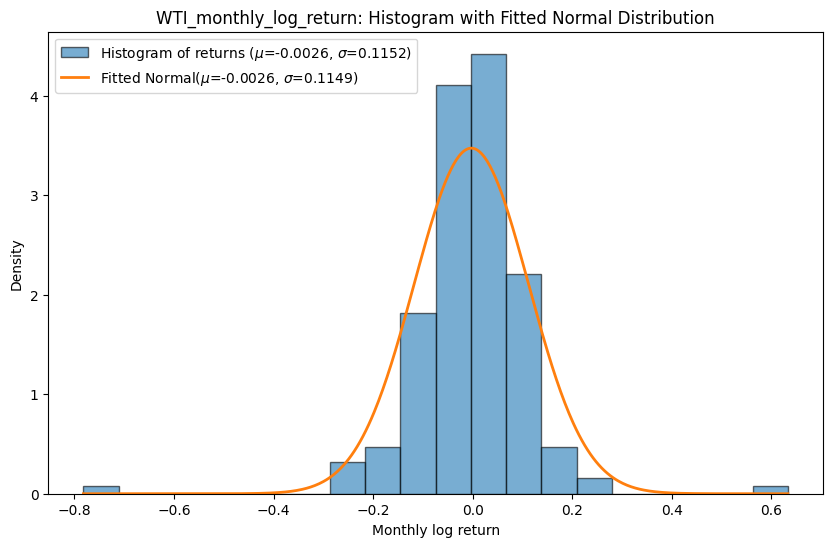

In [12]:
# Plots the histogram with the fitted normal curve
plot_kutosis_vs_normal(monthly_returns, "WTI_monthly_log_return")

In [13]:
# Gets the max JB stat and p-value
asset_jb, stat_jb, pval_jb = highest_jarque_bera(monthly_returns)
print(f"Farthest from normal: {asset_jb}")
print(f"Test Statistic: {stat_jb:.4f}, p-value: {pval_jb}")

Farthest from normal: WTI_monthly_log_return
Test Statistic: 1739.8504, p-value: 0.0


In [14]:
# Runs the full Fed hiking cycle analysis
df_hike_cut = hike_cut_identification(df)
df_cycles = label_hiking_months(df_hike_cut)

print(f"Total hiking-cycle months: {(df_cycles['D_t'] == 1).sum()}")
df_regimes = analyze_monetary_regimes(df, df_cycles)

Total hiking-cycle months: 81

--- Question 9 ---
9(b) Std Dev of SP500 Total Return: 0.0435
9(c) Hiking Cycles -> Mean: 0.0269, IQR: 0.0416
9(d) Easing/Pause Cycles -> Mean: 0.0262, IQR: 0.0552
9(e) t-test -> t-statistic: 0.1173, p-value: 0.9067
     Result: Fail to reject H_0. Returns are NOT significantly different at the 5% level.


In [16]:
data = df.copy()
data["Date"] = pd.to_datetime(data["Date"], format="%m/%d/%y")
data = data.sort_values("Date").reset_index(drop=True)

# Bring over the D_t dummy from df_cycles
data["D_t"] = df_cycles["D_t"]

# Lag the SP500 index
data["SP500_lag"] = data["SPY US INDEX"].shift(1)


data.head(10)

,Date,SXXP Index,SPY US INDEX,NKY INDEX,XAU CURNCY,CL1 COMDTY,SPDIV,RF,DFEDTARU,D_t,SP500_lag
0,2008-12-31,276.76878,90.24,98.07993,875.43,44.60,28.390000,2.87,0.25,0,NaN
1,2009-01-30,245.27160,82.83,88.89192,927.85,41.68,28.013333,3.02,0.25,1,90.24
2,2009-02-27,219.88507,73.93,77.26031,942.32,44.76,27.636667,2.71,0.25,0,82.83
3,2009-03-31,233.43893,79.52,81.62587,919.90,49.66,27.260000,3.16,0.25,0,73.93
4,2009-04-30,264.48381,87.42,89.27354,887.95,51.12,26.703333,3.47,0.25,0,79.52
5,2009-05-29,293.97170,92.53,99.61816,975.75,66.31,26.146667,3.53,0.25,0,87.42
6,2009-06-30,289.19115,91.95,103.38912,930.00,69.89,25.590000,3.52,0.25,0,92.53
7,2009-07-31,320.33931,98.81,109.44552,954.00,69.45,25.026667,3.40,0.25,0,91.95
8,2009-08-31,338.47120,102.46,113.02952,950.94,69.96,24.463333,3.31,0.25,0,98.81
9,2009-09-30,355.04882,105.59,112.99320,1007.60,70.61,23.900000,3.41,0.25,1,102.46
